In [1]:
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import polars as pl
import numpy as np
import os

In [2]:
plt.rcParams["pdf.fonttype"] = 42  # Use TrueType fonts instead of Type 3 fonts
plt.rcParams["ps.fonttype"] = 42  # For PostScript as well, if needed

# Regions and variant summary statistics

### Summaries

In [3]:
regions_t2t = pd.read_csv('../4_regions/regions_2_lifted.tsv', sep='\t')
print(f'Rows: {regions_t2t.shape[0]}')
regions_t2t.sample(3)

Rows: 157


,chr,left_hs1,right_hs1,lead_hs1,rs_lead,lift_success,1kg,nearest_gene
104,chr10,103757207,104072699,103761133,rs12764899,True,True,AS3MT
94,chr3,181903851,182050111,182003047,rs3729674,True,True,PIK3CA
138,chr3,124412982,124568969,124562871,rs58088236,True,True,EAF2


In [4]:
donor_variants = pl.read_csv('../3_variants/donor_subset.tsv', separator='\t')
donor_variants = donor_variants.with_columns((pl.col('chr') + pl.Series(['_']*len(donor_variants)) +
                             pl.col('T2T').cast(pl.String) + pl.Series(['_']*len(donor_variants)) + 
                             pl.col('ref') + pl.Series(['_']*len(donor_variants)) + 
                             pl.col('alt')).alias('variant_id_hs1'))
print(f'Rows: {donor_variants.shape[0]}')
donor_variants.sample(3)

Rows: 168647


chr,T2T,ref,alt,start,stop,lead,rs_lead,lift_success,in_1kg,nearest_gene,variant_id_hs1
str,i64,str,str,i64,i64,i64,str,bool,bool,str,str
"""chr17""",45213245,"""G""","""C""",45205375,45230901,45206875,"""rs5848""",true,true,"""GRN""","""chr17_45213245_G_C"""
"""chr17""",43473931,"""C""","""T""",43406185,43523696,43485959,"""rs12601457""",true,true,"""TUBG1""","""chr17_43473931_C_T"""
"""chr12""",49554133,"""Actat""","""A""",49503038,49731547,49511595,"""rs933738""",true,true,"""KCNH3""","""chr12_49554133_Actat_A"""


In [5]:
counts = donor_variants.group_by('rs_lead').agg(
    pl.col('T2T').count())

In [6]:
print(f'Donor EVs in regions: {donor_variants.shape[0]} / 7 million')
print(f'Most amount of donor variants in one region: {np.max(list(counts["T2T"]))}')
print(f'Least amount of donor variants in one region: {np.min(list(counts["T2T"]))}')
print(f'Mean amount of donor variants in one region: {int(np.round(np.mean(list(counts["T2T"]))))}')

Donor EVs in regions: 168647 / 7 million
Most amount of donor variants in one region: 13931
Least amount of donor variants in one region: 8
Mean amount of donor variants in one region: 1074


In [7]:
regions_t2t['size'] = regions_t2t['right_hs1'] - regions_t2t['left_hs1']

In [8]:
print(f'Absolute genomic coverage of all regions combined: {np.round(np.sum(regions_t2t["size"])/100_000)/10} Mbp / 3.1 Gbp')
print(f'Relative genomic coverage of all regions combined: {np.round(100_000*np.sum(regions_t2t["size"])/3_100_000_000)/1000}%')

Absolute genomic coverage of all regions combined: 16.7 Mbp / 3.1 Gbp
Relative genomic coverage of all regions combined: 0.538%


In [9]:
print(f'Regions which (rs) lead is in 1kg: {regions_t2t[regions_t2t["1kg"] == True].shape[0]}/{regions_t2t.shape[0]}')
print(f'Regions with minimal size (3kbp): {regions_t2t[regions_t2t["size"] == 3000].shape[0]}/{regions_t2t.shape[0]}')
print(f'Regions succesfully lifted to hs1: {regions_t2t[regions_t2t["lift_success"] == True].shape[0]}/{regions_t2t.shape[0]}')

Regions which (rs) lead is in 1kg: 151/157
Regions with minimal size (3kbp): 18/157
Regions succesfully lifted to hs1: 155/157


### Region filters

**Requires external file with variants filtered**

In [10]:
vars_link = "../../../../Manuscript/Tables/caQTL_ASCA_ISM_filt_with_eQTL_info.csv"

In [11]:
vars_filtered = pl.read_csv(vars_link)
print(f'Rows: {vars_filtered.shape[0]}')
vars_filtered.sample(3)

Rows: 1760401


variant_id,variant_type,peak_id,brain_region,cell_type,diff,logfc,max_percentile,model,start_distance,end_distance,af,ma_samples,ma_count,pval_nominal,slope,slope_se,chr,caQTL_pval_adj_full,TEST.SNP.CHROM,TEST.SNP.POS,TEST.SNP.REF.ALLELE,TEST.SNP.ALT.ALLELE,REGION.START,REGION.END,LOGLIKE.NULL,LOGLIKE.ALT,CHISQ,P.VALUE,ALPHA,BETA,PHI,TOTAL.AS.READ.COUNT,REF.AS.READ.COUNT,ALT.AS.READ.COUNT,TOTAL.READ.COUNT,REF_LEN,ALT_LEN,allelic_imbalance,MAX_ALLELE_LEN,pval_adj,signif_fdr05,indel_bin,signif,pval_adj_full,signif_fdr05_full,ASCA_pval_adj_full,asca_fdr_bin,qtl_fdr_bin,abs_allelic_imbalance,abs_slope,allelic_imbalance_0.1,slope_0.1,effect_size_filt,signif_ASCA,signif_caQTL,signif_caQTL_ASCA,signif_caQTL_or_ASCA,signif_caQTL_or_ASCA_fdr001,signif_caQTL_ASCA_no_effect_size_filter,cell_type_corrected,phenotype_id,start_distance_eqtl,end_distance_eqtl,af_eqtl,ma_samples_eqtl,ma_count_eqtl,pval_nominal_eqtl,slope_eqtl,slope_se_eqtl,variant_type_eqtl,ct_reg,signif_eqtl,p_adj
str,str,str,str,str,f64,f64,f64,str,i64,i64,f64,i64,i64,f64,f64,f64,str,f64,str,i64,str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64,i64,i64,f64,i64,f64,bool,str,str,f64,bool,f64,str,str,f64,f64,bool,bool,bool,bool,bool,bool,bool,bool,bool,str,str,i64,i64,f64,i64,i64,f64,f64,f64,str,str,bool,f64
"""chr5_179766294_C_A""","""SNP""","""chr5:179766014-179766514""","""SN""","""Oligo""",0.002191,0.082786,77.5795,"""sn_deepPeak_mean_finetuned""",279,-220,0.362963,79,98,1.3540e-19,0.4567628,0.039553,"""chr5""",6.5899e-16,"""chr5""",179766294,"""C""","""A""",179766014,179766514,-1089.63,-796.31,586.629,0.0,0.0639583,0.755696,0.0012778,5824,205,5619,0,1,1,0.421969,1,0.0,true,"""SNP""","""pval < e-5""",0.0,true,0.0,"""<0.01""","""<0.01""",0.421969,0.4567628,true,true,true,true,true,true,true,true,true,"""Oligo""","""GRM6""",234703,217716,0.346154,67,81,0.842766,0.008079,0.040628,"""snp""","""Oligo, SN""",false,1.0
"""chr17_39345333_C_T""","""SNP""","""chr17:39345062-39345562""","""CC""","""OPC""",0.003873,0.019513,97.90325,"""cc_deepPeak_mean_finetuned""",270,-229,0.331461,99,118,5.4733e-9,-0.393297,0.063075,"""chr17""",0.000003,"""chr17""",39345333,"""C""","""T""",39345062,39345562,-937.19,-930.83,12.715,0.000363,0.586845,0.36312,0.001072,1459,925,534,0,1,1,-0.117754,1,0.013033,true,"""SNP""","""pval > e-5""",0.011452,true,0.01251,"""0.01-0.1""","""<0.01""",0.117754,0.393297,true,true,true,true,true,true,true,true,true,"""OPC""","""MLLT6""",-223026,-247547,0.331492,102,120,0.988648,-0.000729,0.051152,"""snp""","""OPC, CC""",false,1.0
"""chr9_145517960_G_A""","""SNP""","""chr9:145517654-145518154""","""SN""","""Oligo""",-0.000166,-0.006626,71.54375,"""sn_deepPeak_mean_finetuned""",305,-194,0.288889,66,78,3.1136e-7,0.1581383,0.02865,"""chr9""",0.000123,"""chr9""",145517960,"""G""","""A""",145517654,145518154,-135.16,-94.38,81.56,0.0,0.121403,0.737227,0.001198,285,46,239,0,1,1,0.358608,1,0.0,true,"""SNP""","""pval < e-5""",0.0,true,0.0,"""<0.01""","""<0.01""",0.358608,0.1581383,true,true,true,true,true,true,true,true,true,"""Oligo""","""GTF3C4""",636704,611787,0.303419,60,71,0.787157,0.0171857,0.063487,"""snp""","""Oligo, SN""",false,1.0


In [12]:
vars_core = vars_filtered[['signif_caQTL_ASCA','logfc','p_adj','variant_id','phenotype_id','cell_type','brain_region','peak_id']].unique()
vars_core.sample(3)

signif_caQTL_ASCA,logfc,p_adj,variant_id,phenotype_id,cell_type,brain_region,peak_id
bool,f64,f64,str,str,str,str,str
true,0.006256,1.0,"""chr1_91460269_T_C""","""GLMN""","""L5_IT_B""","""CC""","""chr1:91459810-91460310"""
true,0.258927,1.0,"""chr4_44952173_A_G""","""KCTD8""","""Oligo""","""CC""","""chr4:44952072-44952572"""
true,0.06939,1.0,"""chr7_29785639_G_A""","""CHN2""","""L23_IT""","""CC""","""chr7:29785456-29785956"""


In [13]:
# filter for significant caQTL and ASCA alone
vars_ascaqtl = vars_core.filter(pl.col("signif_caQTL_ASCA"))
print('1: ', vars_ascaqtl.shape)

# ascaqtl + crested
vars_crested_ascaqtl = vars_ascaqtl.filter(pl.col('logfc').abs() > 0.2)
print('2: ', vars_crested_ascaqtl.shape)

# ascaqtl + eqtl
vars_ascaqtl_eqtl = vars_ascaqtl.filter(pl.col('p_adj').abs() < 0.05)
print('3: ', vars_ascaqtl_eqtl.shape)

# ascaqtl + eqtl + crested
vars_ascaqtl_eqtl_crested = vars_ascaqtl_eqtl.filter(pl.col('logfc').abs() > 0.2)
print('4: ', vars_ascaqtl_eqtl_crested.shape)

# crested
vars_crested = vars_core.filter(pl.col('logfc').abs() > 0.2)
print('5: ', vars_crested.shape)

# crested + eqtl
vars_crested_eqtl = vars_crested.filter(pl.col('p_adj').abs() < 0.05)
print('6: ', vars_crested_eqtl.shape)

# eqtl
vars_eqtl = vars_core.filter(pl.col('p_adj').abs() < 0.05)
print('7: ', vars_eqtl.shape)

1:  (1659349, 8)
2:  (417149, 8)
3:  (7781, 8)
4:  (1216, 8)
5:  (430133, 8)
6:  (1264, 8)
7:  (8265, 8)


In [14]:
LD_all = vars_filtered.join(donor_variants[['variant_id_hs1','rs_lead']], left_on='variant_id', right_on='variant_id_hs1')
LD_a = vars_ascaqtl.join(donor_variants[['variant_id_hs1','rs_lead']], left_on='variant_id', right_on='variant_id_hs1')
LD_ac = vars_crested_ascaqtl.join(donor_variants[['variant_id_hs1','rs_lead']], left_on='variant_id', right_on='variant_id_hs1')
LD_ae = vars_ascaqtl_eqtl.join(donor_variants[['variant_id_hs1','rs_lead']], left_on='variant_id', right_on='variant_id_hs1')
LD_aec = vars_ascaqtl_eqtl_crested.join(donor_variants[['variant_id_hs1','rs_lead']], left_on='variant_id', right_on='variant_id_hs1')
LD_c = vars_crested.join(donor_variants[['variant_id_hs1','rs_lead']], left_on='variant_id', right_on='variant_id_hs1')
LD_ec = vars_crested_eqtl.join(donor_variants[['variant_id_hs1','rs_lead']], left_on='variant_id', right_on='variant_id_hs1')
LD_e = vars_eqtl.join(donor_variants[['variant_id_hs1','rs_lead']], left_on='variant_id', right_on='variant_id_hs1')

In [15]:
GWAS_hs1 = pd.read_csv('../2_source/GWAS.hs1.tsv', sep='\t', names=['chr','hs1','end','REF','ALT','extra'])
GWAS_hs1['chr'] = GWAS_hs1['chr'].astype(str)

In [16]:
no_border = GWAS_hs1.merge(pd.DataFrame(vars_core, columns=vars_core.columns), left_on='hs1id', right_on='variant_id', how='inner')[[
    'hs1id','chr','hs1','p','logp','phenotype_id','cell_type','brain_region']]

KeyError: 'hs1id'

In [17]:
LD_aec.write_csv('variants/LD_ASCQA_caQTL_eQTL_CREsted.tsv', separator='\t')

In [18]:
print(set(LD_aec['phenotype_id']))

{'SLC2A13', 'PTPN1', 'LRRC37A2', 'LRRC37A', 'CRHR1', 'HLA-DRB5', 'BIN3', 'HLA-DMB', 'MFGE8', 'HLA-DQA2', 'HLA-DRB1', 'TMPRSS5', 'NOTUM', 'ANKRD27', 'KANSL1', 'ARL17B'}


In [19]:
# total_regions_possible = regions_t2t[(regions_t2t['1kg'] == True) & (regions_t2t['lift_success'] == True)].shape[0]
total_regions_possible = regions_t2t[(regions_t2t['lift_success'] == True)].shape[0]

In [20]:
abcd = pd.read_csv('barplot_ABCD.tsv', sep='\t')
abcd['hs1id_short'] = ['_'.join(id.split('_')[:2]) for id in abcd['variant_id']]
abcd.sample(3)

,signif_caQTL_ASCA,logfc,p_adj,variant_id,phenotype_id,cell_type,brain_region,peak_id,rs_lead,A,B,C,D,hs1id_short
30809,True,-0.017348,1.0,chr6_32433482_G_A,FKBPL,L5_IT_B,CC,chr6:32433146-32433646,rs2647066,True,False,False,False,chr6_32433482
18831,True,-0.041182,1.0,chr6_32457093_T_C,LY6G5C,Micro-PVM,CC,chr6:32456802-32457302,rs2647066,True,False,False,False,chr6_32457093
11890,True,0.014058,1.0,chr6_32456852_T_C,TAP2,Micro-PVM,SN,chr6:32456792-32457292,rs2647066,True,False,False,False,chr6_32456852


In [21]:
abcd_p = GWAS_hs1.merge(abcd, left_on='hs1id', right_on='variant_id', how='inner')[[
    'hs1id','chr','hs1','p','logp','phenotype_id','cell_type','brain_region','rs_lead','hs1id_short','A','B','C','D']]

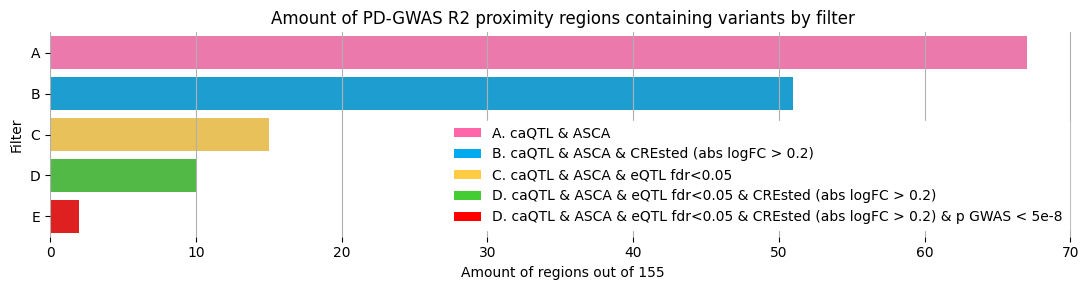

In [22]:
palette=['#f6a','#0ae','#fc4','#4c3','#F00']
fig = plt.figure(figsize=(11,3))
ax = fig.add_subplot(111)
sns.barplot(data=pd.DataFrame({'Filter':[
                                            'A',
                                            'B',
                                            'C',
                                            'D',
                                            'E',
                                        ],
                               '#Regions':[
                                               len(set(LD_a['rs_lead'])),
                                               len(set(LD_ac['rs_lead'])),
                                               len(set(LD_ae['rs_lead'])),
                                               len(set(LD_aec['rs_lead'])),
                                   len(set(abcd_p[(abcd_p['p'] < 5*10**-8) & abcd_p['D']]['rs_lead']))
                               ]}),
            x='#Regions', y='Filter', hue='Filter',
            palette=palette)
plt.title('Amount of PD-GWAS R2 proximity regions containing variants by filter')
plt.xlabel(f'Amount of regions out of {total_regions_possible}')
plt.grid(axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
legend_elements = [
                    Patch(facecolor=palette[0], label='A. caQTL & ASCA'),
                    Patch(facecolor=palette[1], label='B. caQTL & ASCA & CREsted (abs logFC > 0.2)'),
                    Patch(facecolor=palette[2], label='C. caQTL & ASCA & eQTL fdr<0.05'),
                    Patch(facecolor=palette[3], label='D. caQTL & ASCA & eQTL fdr<0.05 & CREsted (abs logFC > 0.2)'),
                    Patch(facecolor=palette[4], label='D. caQTL & ASCA & eQTL fdr<0.05 & CREsted (abs logFC > 0.2) & p GWAS < 5e-8')]
plt.legend(handles=legend_elements, loc='lower right', frameon=True, fancybox=False, framealpha=1, edgecolor='white').set_zorder(12)
plt.tight_layout()
plt.savefig('figs/LD_ASCA_caQTL_eQTL_CREsted.pdf')
plt.show()

In [24]:
abcd_p = abcd.merge(GWAS_hs1, left_on='variant_id', right_on='hs1id', how='left')[[
    'variant_id','peak_id','rs_lead','p'] #,'phenotype_id']
    ].drop_duplicates().groupby(['variant_id','rs_lead']).agg(
        peak_id=pd.NamedAgg(column="peak_id", aggfunc="first"),
        p=pd.NamedAgg(column="p", aggfunc="first"),
    ).reset_index().rename(columns={'rs_lead':'lead_variant_rsid','p':'GWAS_p_val'})

In [25]:
abcd_p.sample(3)

,variant_id,lead_variant_rsid,peak_id,GWAS_p_val
706,chr8_22894195_C_T,rs4872005,chr8:22893884-22894384,1.092000e-06
207,chr17_47012770_G_A,rs2532384,chr17:47012674-47013174,6.108000e-131
424,chr5_138945339_G_A,rs2350640,chr5:138944992-138945492,3.065000e-02


In [83]:
regions = pd.read_csv('regions/regions_2_lifted.tsv', sep='\t')[['rs_lead','lead_hs1','nearest_gene']]
regions.sample(3)

,rs_lead,lead_hs1,nearest_gene
150,rs28628748,79619459,FAM47E-STBD1
24,rs117517602,52305120,PTPN1
16,rs2350640,138969507,REEP2


In [70]:
abcd_p['hs1'] = [int(id.split('_')[1]) for id in abcd_p['variant_id']]

In [71]:
abcd_p_lead = abcd_p.merge(regions, left_on='lead_variant_rsid', right_on='rs_lead')
abcd_p_lead['dist_to_lead'] = abcd_p_lead['lead_hs1'] - abcd_p_lead['hs1']

In [72]:
abcd_p_lead = abcd_p_lead.drop(columns=['hs1','rs_lead','lead_hs1'])

In [73]:
abcd_p_lead.shape

(716, 6)

In [74]:
abcd_p_lead.sample(3)

,variant_id,lead_variant_rsid,peak_id,GWAS_p_val,nearest_gene,dist_to_lead
595,chr6_32446141_T_A,rs2647066,chr6:32445787-32446287,0.000081,HLA-DRB1,-13220
297,chr17_79325350_A_G,rs143392722,chr17:79325100-79325600,0.000001,DNAH17,-6557
539,chr6_32433517_T_A,rs2647066,chr6:32433146-32433646,NaN,HLA-DRB1,-596


In [33]:
KG = pd.read_csv('plink/chrKG.tsv', sep='\t', names=['hg38_id','hg38_id_short','rs'])
KG.sample(3)

,hg38_id,hg38_id_short,rs
71473122,chrX_39031792_G_C,X_39031792,rs6651717
46646556,chr11_56001542_C_G,11_56001542,rs1590692196
27131916,chr6_33066299_C_T,6_33066299,rs68172213


In [34]:
GWAS = pd.read_csv('source/GWAS.hs1', sep='\t')
GWAS.sample(3)

/tmp/ipykernel_3492213/2842324571.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  GWAS = pd.read_csv('source/GWAS.hs1', sep='\t')


,hg38id,hs1id,p,hs1,chr,logp
10502540,chr8_53373641_A_C,chr8_53750130_A_C,0.2965,53750130,8,1.215708
9585530,chr7_13406552_C_T,chr7_13538895_C_T,0.5522,13538895,7,0.593845
8271664,chr5_16555343_G_C,chr5_16494675_G_C,0.3449,16494675,5,1.064501


In [88]:
variant_hs1_rs = GWAS[['hg38id','hs1id','p']].merge(KG[['hg38_id','rs']], left_on='hg38id', right_on='hg38_id')
variant_hs1_rs.sample(3)

,hg38id,hs1id,p,hg38_id,rs
6719515,chr3_5667699_A_T,chr3_5661446_T_A,0.07612,chr3_5667699_A_T,rs13088557
2158621,chr14_53986125_T_G,chr14_48194329_G_T,0.92520,chr14_53986125_T_G,rs2104321
3456721,chr18_55546264_G_C,chr18_55749350_G_C,0.85880,chr18_55546264_G_C,rs79318721


In [90]:
abcd_p_rs = abcd_p_lead.merge(variant_hs1_rs[['hs1id','rs']], left_on='variant_id', right_on='hs1id', how='left').drop(columns=['hs1id']).rename(columns={'rs':'rs_donor'})
abcd_p_rs.sample(3)

,variant_id,lead_variant_rsid,peak_id,GWAS_p_val,nearest_gene,dist_to_lead,rs_donor
81,chr17_46584073_C_A,rs2532384,chr17:46583764-46584264,2.035000e-129,KANSL1,517793,rs77819001
475,chr6_32422971_T_C,rs2647066,chr6:32422634-32423134,NaN,HLA-DRB1,9950,NaN
504,chr6_32430567_T_G,rs2647066,chr6:32430403-32430903,6.200000e-04,HLA-DRB1,2354,rs9270765


In [91]:
r2 = pd.read_csv('plink/r2.tsv', sep='\t', names=['rs_lead', 'rs_variant', 'R2'])
r2.sample(3)

,rs_lead,rs_variant,R2
17466,rs58088236,rs4285028,0.068519
32105,rs4713072,rs9461366,0.054224
81862,rs2532384,rs111413387,0.915771


In [92]:
abcd_p_r2 = abcd_p_rs.merge(r2, left_on=['lead_variant_rsid','rs_donor'], right_on=['rs_lead','rs_variant'], how='left')
abcd_p_r2.sample(3)

,variant_id,lead_variant_rsid,peak_id,GWAS_p_val,nearest_gene,dist_to_lead,rs_donor,rs_lead,rs_variant,R2
678,chr6_32463326_A_G,rs2647066,chr6:32463080-32463580,3.007000e-08,HLA-DRB1,-30405,rs9272214,rs2647066,rs9272214,0.120242
546,chr6_32433767_T_A,rs2647066,chr6:32433713-32434213,2.768000e-08,HLA-DRB1,-846,rs9270914,NaN,NaN,NaN
567,chr6_32439138_C_T,rs2647066,chr6:32439064-32439564,4.379000e-06,HLA-DRB1,-6217,rs36097962,NaN,NaN,NaN


In [96]:
abcd = abcd_p_r2.merge(variant_hs1_rs[['rs','p']], left_on='lead_variant_rsid', right_on='rs', how='left').drop(columns=['rs']).rename(columns={'p':'GWAS_p_value_lead'})
print(abcd.shape)
abcd.sample(3)

(716, 11)


,variant_id,lead_variant_rsid,peak_id,GWAS_p_val,nearest_gene,dist_to_lead,rs_donor,rs_lead,rs_variant,R2,GWAS_p_value_lead
263,chr17_47133794_Cag_C,rs2532384,chr17:47133734-47134234,NaN,KANSL1,-31928,NaN,NaN,NaN,NaN,1.609000e-132
314,chr17_82820682_C_T,rs8074498,chr17:82820556-82821056,1.364000e-07,ASPSCR1,43145,rs34116321,rs8074498,rs34116321,0.693318,4.621000e-09
87,chr17_46609830_C_T,rs2532384,chr17:46609459-46609959,1.006000e-129,KANSL1,492036,rs62054436,rs2532384,rs62054436,0.591653,1.609000e-132


In [97]:
abcd.to_csv('variants/caQTl_ASCA_variant_table.tsv', sep='\t', index=None)

In [34]:
abcd_p_lead.to_csv('variants/caQTl_ASCA_variant_table.tsv', sep='\t', index=None)

In [35]:
plink = pd.read_csv('plink/plink_clean_005.vcor', sep='\t').rename(columns={'#CHROM_A':'chr','POS_A':'lead_hg38','ID_A':'lead_rs',
                        'POS_B':'variant_hg38','ID_B':'variant_rs','PHASED_R2':'R2'}).drop(columns=['CHROM_B'])
plink.sample(3)

,chr,lead_hg38,lead_rs,variant_hg38,variant_rs,R2
43670,7,100492237,rs6979335,100328685,rs117787328,0.414712
71051,16,28893412,rs68040616,28487970,rs34835,0.226050
6297,2,32623787,rs13010404,32066834,rs13017027,0.173654


In [36]:
plink['lead_hg38_short'] = ['chr']*len(plink) + plink['chr'].astype(str) + ['_']*len(plink) + plink['lead_hg38'].astype(str)
plink['variant_hg38_short'] = ['chr']*len(plink) + plink['chr'].astype(str) + ['_']*len(plink) + plink['variant_hg38'].astype(str)

In [130]:
lift = pd.read_csv('source/GWAS.hs1', sep='\t')
lift.sample(3)

/tmp/ipykernel_2345717/3036464022.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  lift = pd.read_csv('source/GWAS.hs1', sep='\t')


,hg38id,hs1id,p,hs1,chr,logp
5503467,chr2_122711368_T_C,chr2_123147076_C_T,0.7291,123147076,2,0.315944
3258205,chr17_55449413_A_G,chr17_56324618_G_A,0.4588,56324618,17,0.779141
7210707,chr4_115546436_A_G,chr4_118849240_A_G,0.9903,118849240,4,0.009747


In [5]:
path = "/staging/leuven/stg_00090/ASA/analysis/Manuscript/Tables/ISM_model_scores_all_combined.parquet"
RAW = pl.scan_parquet(path).filter(
        pl.col("model").is_in(['cc_deepPeak_mean_finetuned', 'sn_deepPeak_mean_finetuned']),
    ).collect()

In [6]:
CRE02 = RAW.filter(pl.col("logfc").abs() > 0.2)
CRE05 = RAW.filter(pl.col("logfc").abs() > 0.5)
CRE1 = RAW.filter(pl.col("logfc").abs() > 1)

In [7]:
print(len(set(CRE02['variant_id'])))
print(len(set(CRE05['variant_id'])))
print(len(set(CRE1['variant_id'])))

911392
215766
51024


In [8]:
GWAS_hs1 = pd.read_csv('source/GWAS.hs1', sep='\t')
GWAS_hs1['chr'] = GWAS_hs1['chr'].astype(str)
GWAS_hs1 = pl.DataFrame(GWAS_hs1)

/tmp/ipykernel_2785850/3722744622.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  GWAS_hs1 = pd.read_csv('source/GWAS.hs1', sep='\t')


In [9]:
CRE02_GWAS = GWAS_hs1.join(CRE02, left_on='hs1id', right_on='variant_id', how='inner', coalesce=False)
CRE05_GWAS = GWAS_hs1.join(CRE05, left_on='hs1id', right_on='variant_id', how='inner', coalesce=False)
CRE1_GWAS = GWAS_hs1.join(CRE1, left_on='hs1id', right_on='variant_id', how='inner', coalesce=False)

In [10]:
print(len(set(CRE02_GWAS['variant_id'])))
print(len(set(CRE05_GWAS['variant_id'])))
print(len(set(CRE1_GWAS['variant_id'])))

377441
88169
20202


In [11]:
CRE02_GWAS_sig = CRE02_GWAS.filter(pl.col('p') < 5*10**-8)
CRE05_GWAS_sig = CRE05_GWAS.filter(pl.col('p') < 5*10**-8)
CRE1_GWAS_sig = CRE1_GWAS.filter(pl.col('p') < 5*10**-8)

In [12]:
print(len(set(CRE02_GWAS_sig['variant_id'])))
print(len(set(CRE05_GWAS_sig['variant_id'])))
print(len(set(CRE1_GWAS_sig['variant_id'])))

669
146
35


In [13]:
CRE02_LD = donor_variants.join(CRE02, left_on='variant_id_hs1', right_on='variant_id', how='inner', coalesce=False)
CRE05_LD = donor_variants.join(CRE05, left_on='variant_id_hs1', right_on='variant_id', how='inner', coalesce=False)
CRE1_LD = donor_variants.join(CRE1, left_on='variant_id_hs1', right_on='variant_id', how='inner', coalesce=False)
CRE02_GWAS_LD = donor_variants.join(CRE02_GWAS, left_on='variant_id_hs1', right_on='variant_id', how='inner', coalesce=False)
CRE05_GWAS_LD = donor_variants.join(CRE05_GWAS, left_on='variant_id_hs1', right_on='variant_id', how='inner', coalesce=False)
CRE1_GWAS_LD = donor_variants.join(CRE1_GWAS, left_on='variant_id_hs1', right_on='variant_id', how='inner', coalesce=False)
CRE02_GWAS_sig_LD = donor_variants.join(CRE02_GWAS_sig, left_on='variant_id_hs1', right_on='variant_id', how='inner', coalesce=False)
CRE05_GWAS_sig_LD = donor_variants.join(CRE05_GWAS_sig, left_on='variant_id_hs1', right_on='variant_id', how='inner', coalesce=False)
CRE1_GWAS_sig_LD = donor_variants.join(CRE1_GWAS_sig, left_on='variant_id_hs1', right_on='variant_id', how='inner', coalesce=False)

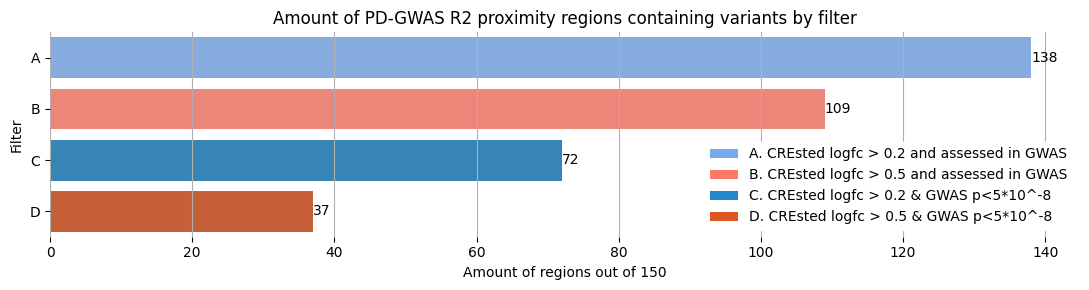

In [14]:
palette=['#7ae','#f76','#28c','#d52']
fig = plt.figure(figsize=(11,3))
# ax = fig.add_subplot(111)
ax = sns.barplot(data=pd.DataFrame({'Filter':[
                                            'A',
                                            'B',
                                            'C',
                                            'D',
                                        ],
                               '#Regions':[
                                               len(set(CRE02_GWAS_LD['rs_lead'])),
                                               len(set(CRE05_GWAS_LD['rs_lead'])),
                                               len(set(CRE02_GWAS_sig_LD['rs_lead'])),
                                               len(set(CRE05_GWAS_sig_LD['rs_lead'])),
                               ]}),
            x='#Regions', y='Filter', hue='Filter', palette=palette)
for container in ax.containers:
    ax.bar_label(container)
legend_elements = [
                    Patch(facecolor=palette[0], label='A. CREsted logfc > 0.2 and assessed in GWAS'),
                    Patch(facecolor=palette[1], label='B. CREsted logfc > 0.5 and assessed in GWAS'),
                    Patch(facecolor=palette[2], label='C. CREsted logfc > 0.2 & GWAS p<5*10^-8'),
                    Patch(facecolor=palette[3], label='D. CREsted logfc > 0.5 & GWAS p<5*10^-8')]
plt.legend(handles=legend_elements, loc='lower right', frameon=True, fancybox=False, framealpha=1,
           edgecolor='white').set_zorder(12)
plt.title('Amount of PD-GWAS R2 proximity regions containing variants by filter')
plt.xlabel(f'Amount of regions out of {150}')
plt.grid(axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.savefig('figs/LD_CREsted_GWASsig.pdf')
plt.show()

In [17]:
len(set(CRE02_GWAS_LD['peak_id']))

2276

In [18]:
len(set(CRE05_GWAS_LD['peak_id']))

604

In [19]:
len(set(CRE02_GWAS_sig_LD['peak_id']))

435

In [20]:
len(set(CRE05_GWAS_sig_LD['peak_id']))

103

In [35]:
len(set(CRE1_GWAS_sig_LD['variant_id']))

24

In [37]:
set(CRE1_GWAS_sig_LD['variant_id'])

{'chr16_31466514_G_C',
 'chr17_15988911_T_C',
 'chr17_46609740_G_A',
 'chr17_46677527_T_C',
 'chr17_46688795_T_C',
 'chr17_46720095_C_T',
 'chr17_46776146_G_A',
 'chr17_46780248_A_G',
 'chr17_46802658_A_G',
 'chr17_46848475_G_A',
 'chr17_47059209_C_A',
 'chr1_52588024_C_T',
 'chr2_135120087_G_A',
 'chr2_135223244_G_A',
 'chr2_61542158_C_T',
 'chr2_95864363_C_G',
 'chr2_95864396_C_T',
 'chr3_154133827_T_G',
 'chr3_164115032_T_A',
 'chr4_93225969_C_T',
 'chr5_61760006_G_A',
 'chr5_61761706_G_A',
 'chr7_23345066_C_T',
 'chr9_34272032_C_T'}

In [32]:
LD_aec.filter(pl.col('phenotype_id') == 'NOTUM')

signif_caQTL_ASCA,logfc,p_adj,variant_id,phenotype_id,cell_type,brain_region,rs_lead
bool,f64,f64,str,str,str,str,str
true,-0.380438,3.9027e-12,"""chr17_82815315_T_C""","""NOTUM""","""Astro""","""SN""","""rs8074498"""


In [29]:
set(LD_ac.filter(pl.col('rs_lead') == 'rs4698412')['variant_id']) #.sort(by='p_adj') #.head(10)

{'chr4_15717886_G_A'}

In [30]:
set(LD_a.filter(pl.col('rs_lead') == 'rs4698412')['variant_id']) #.sort(by='p_adj') #.head(10)

{'chr4_15717656_C_G', 'chr4_15717658_G_A', 'chr4_15717886_G_A'}

In [27]:
LD_a.filter(pl.col('phenotype_id') == 'CD83').sort(by='p_adj').head(10)

signif_caQTL_ASCA,logfc,p_adj,variant_id,phenotype_id,cell_type,brain_region,rs_lead
bool,f64,f64,str,str,str,str,str
true,0.352832,1.0,"""chr6_13574011_Agtag_A""","""CD83""","""Micro-PVM""","""CC""","""rs7741241"""


In [28]:
LD_aec.filter(pl.col('phenotype_id') == 'HLA-DRB1')

signif_caQTL_ASCA,logfc,p_adj,variant_id,phenotype_id,cell_type,brain_region,rs_lead
bool,f64,f64,str,str,str,str,str
true,1.859832,0.024549,"""chr6_32421885_C_G""","""HLA-DRB1""","""Micro-PVM""","""SN""","""rs2647066"""
true,-0.2796,0.030942,"""chr6_32424378_G_A""","""HLA-DRB1""","""Micro-PVM""","""SN""","""rs2647066"""
true,0.389096,0.000062,"""chr6_32451985_A_G""","""HLA-DRB1""","""Micro-PVM""","""SN""","""rs2647066"""
true,0.328526,0.006847,"""chr6_32457267_A_G""","""HLA-DRB1""","""L23_IT""","""CC""","""rs2647066"""


In [26]:
LD_aec.filter(pl.col('phenotype_id') == 'HLA-DRB5')

signif_caQTL_ASCA,logfc,p_adj,variant_id,phenotype_id,cell_type,brain_region,rs_lead
bool,f64,f64,str,str,str,str,str
true,0.328526,0.00426,"""chr6_32457267_A_G""","""HLA-DRB5""","""L23_IT""","""CC""","""rs2647066"""


In [27]:
LD_aec.filter(pl.col('phenotype_id') == 'HLA-DQA2')

signif_caQTL_ASCA,logfc,p_adj,variant_id,phenotype_id,cell_type,brain_region,rs_lead
bool,f64,f64,str,str,str,str,str
true,0.389096,0.008207,"""chr6_32451985_A_G""","""HLA-DQA2""","""Micro-PVM""","""SN""","""rs2647066"""


In [28]:
LD_aec.filter(pl.col('phenotype_id') == 'HLA-DMB')

signif_caQTL_ASCA,logfc,p_adj,variant_id,phenotype_id,cell_type,brain_region,rs_lead
bool,f64,f64,str,str,str,str,str
true,0.328526,0.007554,"""chr6_32457267_A_G""","""HLA-DMB""","""L23_IT""","""CC""","""rs2647066"""


In [36]:
LD_a_ = LD_a.with_columns(pl.col('signif_caQTL_ASCA').alias('A'))
LD_ac_ = LD_ac.with_columns(pl.col('signif_caQTL_ASCA').alias('B'))
LD_ae_ = LD_ae.with_columns(pl.col('signif_caQTL_ASCA').alias('C'))
LD_aec_ = LD_aec.with_columns(pl.col('signif_caQTL_ASCA').alias('D'))
joined = LD_a_.join(LD_ac_[['variant_id','phenotype_id','cell_type','rs_lead','brain_region','B']],
                   on=['variant_id','phenotype_id','cell_type','rs_lead','brain_region'], how='outer', coalesce=True).fill_null(False)
joined = joined.join(LD_ae_[['variant_id','phenotype_id','cell_type','rs_lead','brain_region','C']],
                   on=['variant_id','phenotype_id','cell_type','rs_lead','brain_region'], how='outer', coalesce=True).fill_null(False)
joined = joined.join(LD_aec_[['variant_id','phenotype_id','cell_type','rs_lead','brain_region','D']],
                   on=['variant_id','phenotype_id','cell_type','rs_lead','brain_region'], how='outer', coalesce=True).fill_null(False)

/tmp/ipykernel_2345717/468557538.py:5: DeprecationWarning: use of `how='outer'` should be replaced with `how='full'`.
(Deprecated in version 0.20.29)
  joined = LD_a_.join(LD_ac_[['variant_id','phenotype_id','cell_type','rs_lead','brain_region','B']],
/tmp/ipykernel_2345717/468557538.py:7: DeprecationWarning: use of `how='outer'` should be replaced with `how='full'`.
(Deprecated in version 0.20.29)
  joined = joined.join(LD_ae_[['variant_id','phenotype_id','cell_type','rs_lead','brain_region','C']],
/tmp/ipykernel_2345717/468557538.py:9: DeprecationWarning: use of `how='outer'` should be replaced with `how='full'`.
(Deprecated in version 0.20.29)
  joined = joined.join(LD_aec_[['variant_id','phenotype_id','cell_type','rs_lead','brain_region','D']],


In [37]:
joined

signif_caQTL_ASCA,logfc,p_adj,variant_id,phenotype_id,cell_type,brain_region,peak_id,rs_lead,A,B,C,D
bool,f64,f64,str,str,str,str,str,str,bool,bool,bool,bool
true,0.014056,1.0,"""chr6_32463564_A_C""","""GPANK1""","""Micro-PVM""","""CC""","""chr6:32463080-32463580""","""rs2647066""",true,false,false,false
true,-0.015461,1.0,"""chr6_32439138_C_T""","""HSPA1L""","""L6_CT""","""CC""","""chr6:32439064-32439564""","""rs2647066""",true,false,false,false
true,-0.009867,1.0,"""chr13_48598149_C_T""","""CDADC1""","""Astro""","""SN""","""chr13:48597907-48598407""","""rs1198499""",true,false,false,false
true,-0.000105,1.0,"""chr6_32456951_C_T""","""SLC44A4""","""Micro-PVM""","""SN""","""chr6:32456792-32457292""","""rs2647066""",true,false,false,false
true,-0.123703,1.0,"""chr17_46609601_C_G""","""SPATA32""","""OPC""","""SN""","""chr17:46609449-46609949""","""rs2532384""",true,false,false,false
…,…,…,…,…,…,…,…,…,…,…,…,…
true,-0.030549,1.0,"""chr6_32452056_G_C""","""PHF1""","""L23_IT""","""CC""","""chr6:32451717-32452217""","""rs2647066""",true,false,false,false
true,-0.300424,1.0,"""chr17_46827644_T_C""","""NSF""","""L23_IT""","""CC""","""chr17:46827307-46827807""","""rs2532384""",true,true,false,false
true,-0.056391,1.0,"""chr6_32457093_T_C""","""STK19""","""Micro-PVM""","""SN""","""chr6:32456792-32457292""","""rs2647066""",true,false,false,false


In [39]:
joined.write_csv('barplot_ABCD.tsv', separator='\t')

In [121]:
path = "/staging/leuven/stg_00090/ASA/analysis/Manuscript/Tables/ISM_model_scores_all_combined.parquet"

df_full = pl.scan_parquet(
        path
    ).filter(
        pl.col("model").is_in(['cc_deepPeak_mean_finetuned', 'sn_deepPeak_mean_finetuned']),
        pl.col("logfc").abs() > 0.5 # set stringent filtering
    ).collect()

In [122]:
df_full

variant_id,variant_type,peak_id,brain_region,cell_type,diff,logfc,max_percentile,model
str,str,str,str,str,f64,f64,f64,str
"""chrX_39870111_T_C""","""SNP""","""chrX:39869864-39870364""","""CC""","""Oligo""",-8.309817,-3.886358,99.9985,"""cc_deepPeak_mean_finetuned"""
"""chr5_149598001_A_G""","""SNP""","""chr5:149597729-149598229""","""CC""","""Oligo""",-7.099959,-4.815594,99.99375,"""cc_deepPeak_mean_finetuned"""
"""chr7_151836928_G_A""","""SNP""","""chr7:151836714-151837214""","""CC""","""immune""",-7.077504,-3.910425,100.0,"""cc_deepPeak_mean_finetuned"""
"""chrX_39078269_C_T""","""SNP""","""chrX:39078081-39078581""","""CC""","""Oligo""",-6.941272,-2.089209,99.9985,"""cc_deepPeak_mean_finetuned"""
"""chr12_6238542_T_G""","""SNP""","""chr12:6238239-6238739""","""CC""","""Oligo""",-6.639475,-2.018833,99.99825,"""cc_deepPeak_mean_finetuned"""
…,…,…,…,…,…,…,…,…
"""chr10_89050134_G_A""","""SNP""","""chr10:89049841-89050341""","""SN""","""Oligo""",6.717747,2.608872,99.98725,"""sn_deepPeak_mean_finetuned"""
"""chr3_45562003_G_A""","""SNP""","""chr3:45561858-45562358""","""SN""","""Oligo""",6.794835,2.784541,99.987,"""sn_deepPeak_mean_finetuned"""
"""chr11_73581666_G_A""","""SNP""","""chr11:73581396-73581896""","""SN""","""Oligo""",7.119482,1.054314,99.99925,"""sn_deepPeak_mean_finetuned"""


In [126]:
donor_variants

chr,T2T,ref,alt,start,stop,lead,rs_lead,lift_success,in_1kg,nearest_gene,variant_id_hs1
str,i64,str,str,i64,i64,i64,str,bool,bool,str,str
"""chr1""",52576006,"""Cg""","""C""",52575966,52754589,52606191,"""rs377808""",true,true,"""ZYG11B""","""chr1_52576006_Cg_C"""
"""chr1""",52576066,"""A""","""G""",52575966,52754589,52606191,"""rs377808""",true,true,"""ZYG11B""","""chr1_52576066_A_G"""
"""chr1""",52576283,"""T""","""TTAAAAA""",52575966,52754589,52606191,"""rs377808""",true,true,"""ZYG11B""","""chr1_52576283_T_TTAAAAA"""
"""chr1""",52576284,"""T""","""TAAAAATA,TAAAAAATA""",52575966,52754589,52606191,"""rs377808""",true,true,"""ZYG11B""","""chr1_52576284_T_TAAAAATA,TAAAA…"
"""chr1""",52576653,"""T""","""C""",52575966,52754589,52606191,"""rs377808""",true,true,"""ZYG11B""","""chr1_52576653_T_C"""
…,…,…,…,…,…,…,…,…,…,…,…
"""chr21""",43578372,"""C""","""CT""",43437162,43578901,43524807,"""rs8130097""",true,true,"""ADARB1""","""chr21_43578372_C_CT"""
"""chr21""",43578434,"""C""","""T""",43437162,43578901,43524807,"""rs8130097""",true,true,"""ADARB1""","""chr21_43578434_C_T"""
"""chr21""",43578468,"""T""","""A""",43437162,43578901,43524807,"""rs8130097""",true,true,"""ADARB1""","""chr21_43578468_T_A"""


In [128]:
len(set(df_full.join(donor_variants[['variant_id_hs1','rs_lead']], left_on=['variant_id'],
                     right_on=['variant_id_hs1'])['rs_lead']))

125

In [130]:
df_full.join(donor_variants[['variant_id_hs1','rs_lead']], left_on=['variant_id'],
                     right_on=['variant_id_hs1'])

variant_id,variant_type,peak_id,brain_region,cell_type,diff,logfc,max_percentile,model,rs_lead
str,str,str,str,str,f64,f64,f64,str,str
"""chr1_154266688_T_C""","""SNP""","""chr1:154266443-154266943""","""CC""","""Oligo""",-4.180467,-1.698993,99.98825,"""cc_deepPeak_mean_finetuned""","""rs2230288"""
"""chr14_82227159_G_C""","""SNP""","""chr14:82226815-82227315""","""CC""","""immune""",-3.754379,-1.887898,99.99625,"""cc_deepPeak_mean_finetuned""","""rs979812"""
"""chr5_61719949_C_A""","""SNP""","""chr5:61719667-61720167""","""CC""","""Oligo""",-2.051448,-3.788823,99.9035,"""cc_deepPeak_mean_finetuned""","""rs1867598"""
"""chr5_61719961_T_A""","""SNP""","""chr5:61719667-61720167""","""CC""","""Oligo""",-1.854165,-2.629842,99.9035,"""cc_deepPeak_mean_finetuned""","""rs1867598"""
"""chr8_1545646_G_A""","""SNP""","""chr8:1545373-1545873""","""CC""","""Micro-PVM""",-1.735873,-1.700347,99.9035,"""cc_deepPeak_mean_finetuned""","""rs10087654"""
…,…,…,…,…,…,…,…,…,…
"""chr3_58324246_G_T""","""SNP""","""chr3:58324055-58324555""","""SN""","""Oligo""",1.797489,2.781738,99.78725,"""sn_deepPeak_mean_finetuned""","""rs56384862"""
"""chr2_135176996_T_C""","""SNP""","""chr2:135176694-135177194""","""SN""","""Micro-PVM""",2.589513,1.366725,99.94275,"""sn_deepPeak_mean_finetuned""","""rs6758044"""
"""chr15_86710020_A_G""","""SNP""","""chr15:86709648-86710148""","""SN""","""Astro""",2.637321,0.582818,99.99925,"""sn_deepPeak_mean_finetuned""","""rs34631560"""
